# Face mask detection

Here I am going to detect whether a person is wearing mask or not. I am focussing on only two classes that are 'face_with_mask' and face_no_mask'.

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import matplotlib.patches as patches
import tensorflow as tf
from keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Dropout
from keras.models import Sequential

In [2]:
pip install mtcnn

In [3]:
from mtcnn.mtcnn import MTCNN

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wobotintelligence/face-mask-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-detection-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-detection-dataset


# Loading datasets

In [5]:
images=os.path.join("/root/.cache/kagglehub/datasets/wobotintelligence/face-mask-detection-dataset/versions/4/Medical mask/Medical mask/Medical Mask/images")
annotations=os.path.join("/root/.cache/kagglehub/datasets/wobotintelligence/face-mask-detection-dataset/versions/4/Medical mask/Medical mask/Medical Mask/annotations")
train=pd.read_csv(os.path.join("/root/.cache/kagglehub/datasets/wobotintelligence/face-mask-detection-dataset/versions/4/train.csv"))
submission=pd.read_csv(os.path.join("/root/.cache/kagglehub/datasets/wobotintelligence/face-mask-detection-dataset/versions/4/submission.csv"))

In [6]:
print(len(train))
train.head()

15412


,name,x1,x2,y1,y2,classname
0,2756.png,69,126,294,392,face_with_mask
1,2756.png,505,10,723,283,face_with_mask
2,2756.png,75,252,264,390,mask_colorful
3,2756.png,521,136,711,277,mask_colorful
4,6098.jpg,360,85,728,653,face_no_mask


In [7]:
print(len(submission))
submission.head()

8142


,name,x1,x2,y1,y2,classname
0,1800.jpg,NaN,NaN,NaN,NaN,NaN
1,1800.jpg,NaN,NaN,NaN,NaN,NaN
2,1800.jpg,NaN,NaN,NaN,NaN,NaN
3,1799.jpg,NaN,NaN,NaN,NaN,NaN
4,1799.jpg,NaN,NaN,NaN,NaN,NaN


In [8]:
len(os.listdir(images))

6024

## We are having 6024 images.

In [9]:
a=os.listdir(images)
b=os.listdir(annotations)
a.sort()
b.sort()

In [10]:
print(len(b),len(a))

4326 6024


## Data Exploration and Visualization

In [11]:
train_images=a[1698:]
test_images=a[:1698]

In [12]:
test_images[0]

'0001.jpg'

Let's see some of the images.

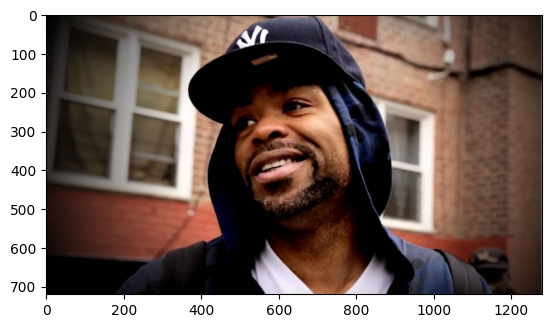

In [13]:
img=plt.imread(os.path.join(images,test_images[0]))
plt.imshow(img)
plt.show()

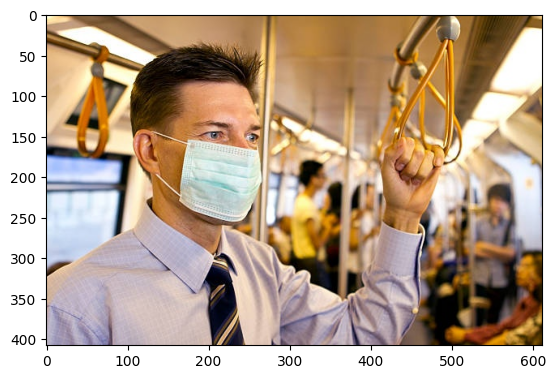

In [14]:
img=plt.imread(os.path.join(images,train_images[1]))
plt.imshow(img)
plt.show()

In [15]:
options=['face_with_mask','face_no_mask']
train= train[train['classname'].isin(options)]
train.sort_values('name',axis=0,inplace=True)

[[np.int64(112), np.int64(113), np.int64(262), np.int64(307)]]


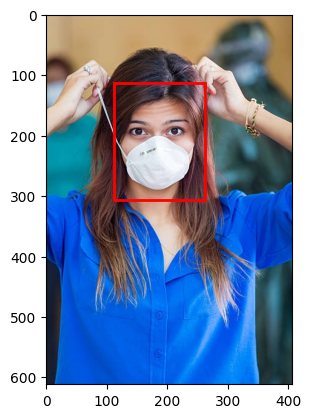

In [16]:
bbox=[]
for i in range(len(train)):
    arr=[]
    for j in train.iloc[i][["x1",'x2','y1','y2']]:
        arr.append(j)
    bbox.append(arr)
train["bbox"]=bbox
def get_boxes(id):
    boxes=[]
    for i in train[train["name"]==str(id)]["bbox"]:
        boxes.append(i)
    return boxes
print(get_boxes(train_images[3]))
image=train_images[3]

img=plt.imread(os.path.join(images,image))

fig,ax = plt.subplots(1)
ax.imshow(img)
boxes=get_boxes(image)
for box in boxes:
    rect = patches.Rectangle((box[0],box[1]),box[2]-box[0],box[3]-box[1],linewidth=2,edgecolor='r',facecolor='none')
    ax.add_patch(rect)
plt.show()

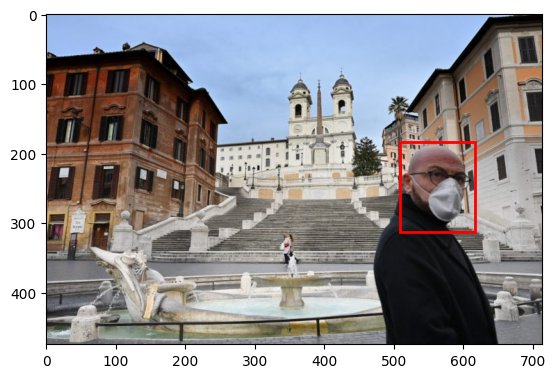

In [17]:
image=train_images[5]

img=plt.imread(os.path.join(images,image))

fig,ax = plt.subplots(1)
ax.imshow(img)
boxes=get_boxes(image)
for box in boxes:
    rect = patches.Rectangle((box[0],box[1]),box[2]-box[0],box[3]-box[1],linewidth=2,edgecolor='r',facecolor='none')
    ax.add_patch(rect)
plt.show()

<BarContainer object of 2 artists>

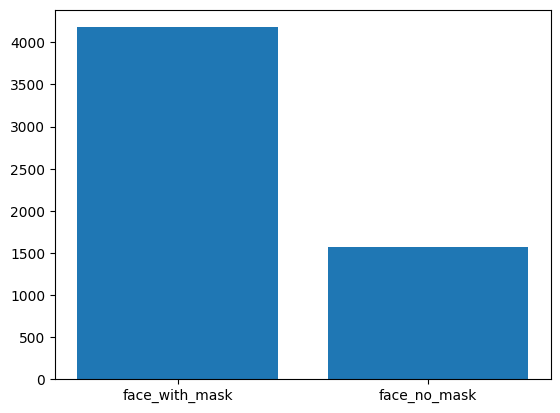

In [18]:
plt.bar(['face_with_mask','face_no_mask'],train.classname.value_counts())

# Creating training data

In [19]:
img_size=50
data=[]
path='/kaggle/input/face-mask-detection-dataset/Medical mask/Medical mask/Medical Mask/images/'
def create_data():
       for i in range(len(train)):
            arr=[]
            for j in train.iloc[i]:
                   arr.append(j)
            img_array=cv2.imread(os.path.join(images,arr[0]),cv2.IMREAD_GRAYSCALE)
            crop_image = img_array[arr[2]:arr[4],arr[1]:arr[3]]
            new_img_array=cv2.resize(crop_image,(img_size,img_size))
            data.append([new_img_array,arr[5]])
create_data()

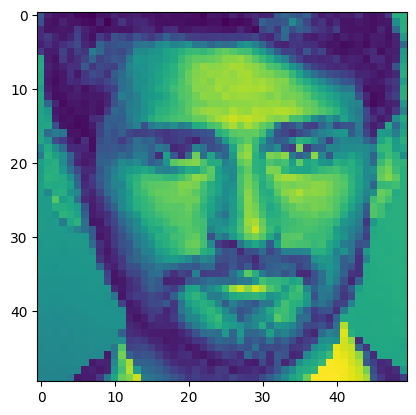

In [20]:
data[0][0]
plt.imshow(data[0][0])

In [21]:
x=[]
y=[]
for features, labels in data:
    x.append(features)
    y.append(labels)
from sklearn.preprocessing import LabelEncoder
lbl=LabelEncoder()
y=lbl.fit_transform(y)

In [22]:
x=np.array(x).reshape(-1,50,50,1)
x=tf.keras.utils.normalize(x,axis=1)
from keras.utils import to_categorical
y = to_categorical(y)

# Model Fitting

In [23]:
from keras.layers import LSTM
model=Sequential()
model.add(Conv2D(100,(3,3),input_shape=x.shape[1:],activation='relu',strides=2))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(2, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
opt = tf.keras.optimizers.Adam(learning_rate=1e-3, decay=1e-5)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x,y,epochs=5,batch_size=5)

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7384 - loss: 0.5390
Epoch 2/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7869 - loss: 0.4524
Epoch 3/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8254 - loss: 0.3937
Epoch 4/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8401 - loss: 0.3582
Epoch 5/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8601 - loss: 0.3246
Epoch 6/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8723 - loss: 0.2931
Epoch 7/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8831 - loss: 0.2672
Epoch 8/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8923 - loss: 0.2461
Epoch 9/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9057 - loss: 0.2188
Epoch 10/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9099 - loss: 0.2102


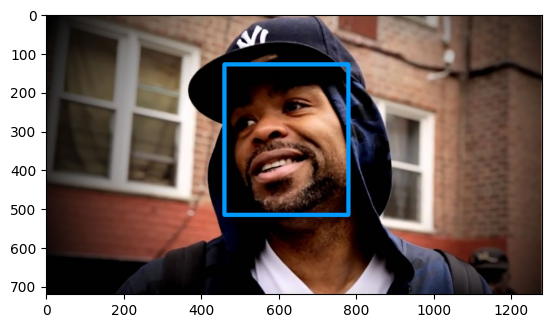

In [26]:
from mtcnn.mtcnn import MTCNN
import matplotlib.pyplot as plt
import os
import cv2 # Import OpenCV

# Re-define 'images', 'a', and 'test_images' as these variables were cleared during runtime restart
images=os.path.join("/root/.cache/kagglehub/datasets/wobotintelligence/face-mask-detection-dataset/versions/4/Medical mask/Medical mask/Medical Mask/images")
a=os.listdir(images)
a.sort() # Ensure 'a' is sorted for consistent test_images definition
test_images=a[:1698] # Re-define test_images

detector=MTCNN()
img=plt.imread(os.path.join(images,test_images[0]))

# Create a writable copy of the image because plt.imread often returns read-only arrays
# and cv2.rectangle modifies the image in place.
img_writable = img.copy()

face=detector.detect_faces(img_writable) # Pass the writable image to the detector
for face in face:
        bounding_box=face['box']
        x=cv2.rectangle(img_writable, # Use the writable copy for drawing rectangles
              (bounding_box[0], bounding_box[1]),
              (bounding_box[0]+bounding_box[2], bounding_box[1] + bounding_box[3]),
              (0,155,255),
              10)
        plt.imshow(x)

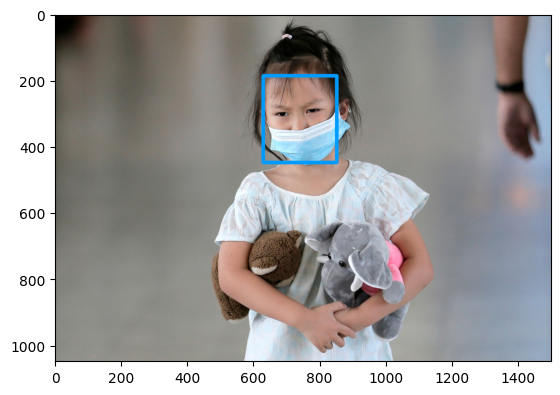

In [28]:
img=plt.imread(os.path.join(images,test_images[3]))

# Create a writable copy of the image because plt.imread often returns read-only arrays
# and cv2.rectangle modifies the image in place.
img_writable = img.copy()

face=detector.detect_faces(img_writable) # Use the writable copy for detection
for face in face:
        bounding_box=face['box']
        x=cv2.rectangle(img_writable, # Use the writable copy for drawing rectangles
              (bounding_box[0], bounding_box[1]),
              (bounding_box[0]+bounding_box[2], bounding_box[1] + bounding_box[3]),
              (0,155,255),
              10)
        plt.imshow(x)

## Face Detection Loop

In [34]:
from mtcnn import MTCNN
from tqdm import tqdm
import cv2
import os

detector = MTCNN()
results = []

for image_filename in tqdm(test_images):

    img = cv2.imread(os.path.join(images, image_filename))

    if img is None:
        continue

    h, w = img.shape[:2]

    if max(h, w) > 800:
        scale = 800 / max(h, w)
        img = cv2.resize(img, (int(w*scale), int(h*scale)))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    try:
        faces = detector.detect_faces(img)

        for face in faces:
            results.append([
                image_filename,
                face['box']
            ])

    except ValueError:
        continue

100%|██████████| 1698/1698 [07:12<00:00,  3.93it/s]


## Post-processing and Submission

In [35]:
negative=[]
for i in test:
    for j in i[1]:
        if j<0:
            negative.append(i)


In [36]:
test_data=[]
def create_test_data():
            for j in test:
                if j not in negative:
                    img=cv2.imread(os.path.join(images,j[0]),cv2.IMREAD_GRAYSCALE)
                    img=img[j[1][1]:j[1][1]+j[1][3],j[1][0]:j[1][0]+j[1][2]]
                    new_img=cv2.resize(img,(50,50))
                    new_img=new_img.reshape(-1,50,50,1)
                    predict=model.predict(new_img)
                    test_data.append([j,predict])

create_test_data()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


In [37]:
image=[]
classname=[]
for i,j in test_data:
    classname.append(np.argmax(j))
    image.append(i)
df=pd.DataFrame(columns=['image','classname'])
df['image']=image
df['classname']=classname
df['classname']=lbl.inverse_transform(df['classname'])
image=[]
x1=[]
x2=[]
y1=[]
y2=[]
for i in df['image']:
    image.append(i[0])
    x1.append(i[1][0])
    x2.append(i[1][1])
    y1.append(i[1][2])
    y2.append(i[1][3])
df['name']=image
df['x1']=x1
df['x2']=x2
df['y1']=y1
df['y2']=y2
df.drop(['image'],axis=1,inplace=True)

In [38]:
df.sort_values('name',axis=0,inplace=True,ascending=False)
df.to_csv('submission_1.csv')